# Goal Type x Agent x Reversibility effect

Import Libraries

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import chi2_contingency
from statsmodels.stats.contingency_tables import Table

import seaborn as sns

## Overall Subgroup:

1. Contigency Table
2. Proportions
3. Chi-Square Test
4. Expected Counts
5. Cramér's V
6. Standardized Residuals
7. Interpretation

Read data

In [21]:
subgroup_theoretical = pd.read_csv("../../data/processed/subgroup_theoretical.csv")

1. Contingency Table

In [22]:
contingency = pd.crosstab(
    [subgroup_theoretical["Goal_Type"], subgroup_theoretical["Agent"], subgroup_theoretical["Consequent_Reversibility"]],
    subgroup_theoretical["Response_Full"]
)

contingency

Response_Full                                     L1_transfer  L2_other  \
Goal_Type         Agent Consequent_Reversibility                          
goal_frequent     0     Yes                                13        14   
                  1     Yes                                12         2   
goal_non_frequent 0     No                                 21         9   
                  1     No                                 16         1   
no_goal           0     Yes                                23         8   
                  1     Yes                                11         4   

Response_Full                                     correct  
Goal_Type         Agent Consequent_Reversibility           
goal_frequent     0     Yes                            14  
                  1     Yes                            10  
goal_non_frequent 0     No                             12  
                  1     No                              7  
no_goal           0     Yes                             9  
                  1     Yes                             9

2. Proportions

In [23]:
proportions = pd.crosstab(
    [subgroup_theoretical["Goal_Type"], subgroup_theoretical["Agent"], subgroup_theoretical["Consequent_Reversibility"]],
    subgroup_theoretical["Response_Full"],
    normalize="index"
)

proportions

Response_Full                                     L1_transfer  L2_other  \
Goal_Type         Agent Consequent_Reversibility                          
goal_frequent     0     Yes                          0.317073  0.341463   
                  1     Yes                          0.500000  0.083333   
goal_non_frequent 0     No                           0.500000  0.214286   
                  1     No                           0.666667  0.041667   
no_goal           0     Yes                          0.575000  0.200000   
                  1     Yes                          0.458333  0.166667   

Response_Full                                      correct  
Goal_Type         Agent Consequent_Reversibility            
goal_frequent     0     Yes                       0.341463  
                  1     Yes                       0.416667  
goal_non_frequent 0     No                        0.285714  
                  1     No                        0.291667  
no_goal           0     Yes                       0.225000  
                  1     Yes                       0.375000

3. Chi-Square Test

In [24]:
chi2, p, dof, expected = chi2_contingency(contingency)

print(f"Chi-square: {chi2:.3f}")
print(f"p-value: {p:.4f}")
print(f"Degrees of freedom: {dof}")

Chi-square: 16.139
p-value: 0.0957
Degrees of freedom: 10


No, there is no evidence that response distribution differs across reversibility conditions.

4. Expected Counts

In [25]:
expected_df = pd.DataFrame(
    expected,
    index=contingency.index,
    columns=contingency.columns
)

expected_df

Response_Full                                     L1_transfer  L2_other  \
Goal_Type         Agent Consequent_Reversibility                          
goal_frequent     0     Yes                         20.184615  7.989744   
                  1     Yes                         11.815385  4.676923   
goal_non_frequent 0     No                          20.676923  8.184615   
                  1     No                          11.815385  4.676923   
no_goal           0     Yes                         19.692308  7.794872   
                  1     Yes                         11.815385  4.676923   

Response_Full                                       correct  
Goal_Type         Agent Consequent_Reversibility             
goal_frequent     0     Yes                       12.825641  
                  1     Yes                        7.507692  
goal_non_frequent 0     No                        13.138462  
                  1     No                         7.507692  
no_goal           0     Yes                       12.512821  
                  1     Yes                        7.507692

In [26]:
print(expected_df < 5)

Response_Full                                     L1_transfer  L2_other  \
Goal_Type         Agent Consequent_Reversibility                          
goal_frequent     0     Yes                             False     False   
                  1     Yes                             False      True   
goal_non_frequent 0     No                              False     False   
                  1     No                              False      True   
no_goal           0     Yes                             False     False   
                  1     Yes                             False      True   

Response_Full                                     correct  
Goal_Type         Agent Consequent_Reversibility           
goal_frequent     0     Yes                         False  
                  1     Yes                         False  
goal_non_frequent 0     No                          False  
                  1     No                          False  
no_goal           0     Yes            

There are X groups with fewer than 5 observations.

5. Cramér's V

In [27]:
n = contingency.values.sum()

cramers_v = np.sqrt(
    chi2 / (n * (min(contingency.shape) - 1))
)

print(f"Cramér's V: {cramers_v:.3f}")

Cramér's V: 0.203


V = 0.104: the effect size is small

6. Standardized Residuals

In [28]:
residuals = (
    contingency - expected
) / np.sqrt(expected)

residuals

Response_Full                                     L1_transfer  L2_other  \
Goal_Type         Agent Consequent_Reversibility                          
goal_frequent     0     Yes                         -1.599165  2.126310   
                  1     Yes                          0.053709 -1.237815   
goal_non_frequent 0     No                           0.071050  0.285012   
                  1     No                           1.217395 -1.700217   
no_goal           0     Yes                          0.745378  0.073472   
                  1     Yes                         -0.237213 -0.313011   

Response_Full                                      correct  
Goal_Type         Agent Consequent_Reversibility            
goal_frequent     0     Yes                       0.327915  
                  1     Yes                       0.909596  
goal_non_frequent 0     No                       -0.314084  
                  1     No                       -0.185288  
no_goal           0     Yes                      -0.993067  
                  1     Yes                       0.544634

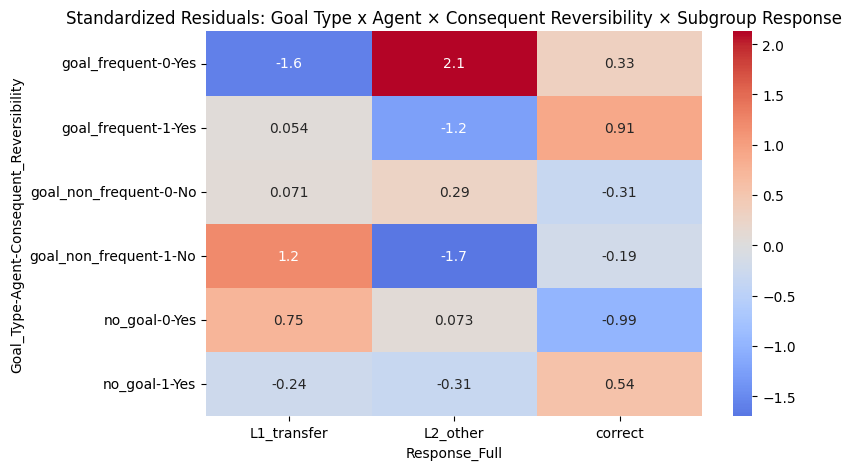

In [29]:
plt.figure(figsize=(8, 5))

sns.heatmap(
    residuals,
    annot=True,
    cmap="coolwarm",
    center=0
)

plt.title("Standardized Residuals: Goal Type x Agent × Consequent Reversibility × Subgroup Response")
plt.show()

7. Interpretation

Interpretation:

- χ² significant / not significant
- Effect size
- Cells driving the association
- Does this support the reversibility hypothesis?
- What remains unexplained?



## Actors Subgroup:

1. Contigency Table
2. Proportions
3. Chi-Square Test
4. Expected Counts
5. Cramér's V
6. Standardized Residuals
7. Interpretation

Read data

In [30]:
subgroup_actors = subgroup_theoretical[subgroup_theoretical["Focus"] == "I"].copy()

1. Contingency Table

In [31]:
contingency = pd.crosstab(
    [subgroup_actors["Goal_Type"], subgroup_actors["Agent"], subgroup_actors["Consequent_Reversibility"]],
    subgroup_actors["Response_Full"]
)

contingency

Response_Full                                     L1_transfer  L2_other  \
Goal_Type         Agent Consequent_Reversibility                          
goal_frequent     0     Yes                                 6         8   
                  1     Yes                                 7         2   
goal_non_frequent 0     No                                  7         8   
                  1     No                                 11         1   
no_goal           0     Yes                                13         3   
                  1     Yes                                 9         2   

Response_Full                                     correct  
Goal_Type         Agent Consequent_Reversibility           
goal_frequent     0     Yes                             9  
                  1     Yes                             7  
goal_non_frequent 0     No                              9  
                  1     No                              4  
no_goal           0     Yes                             6  
                  1     Yes                             5

2. Proportions

In [32]:
proportions = pd.crosstab(
    [subgroup_actors["Goal_Type"], subgroup_actors["Agent"], subgroup_actors["Consequent_Reversibility"]],
    subgroup_actors["Response_Full"],
    normalize="index"
)

proportions

Response_Full                                     L1_transfer  L2_other  \
Goal_Type         Agent Consequent_Reversibility                          
goal_frequent     0     Yes                          0.260870  0.347826   
                  1     Yes                          0.437500  0.125000   
goal_non_frequent 0     No                           0.291667  0.333333   
                  1     No                           0.687500  0.062500   
no_goal           0     Yes                          0.590909  0.136364   
                  1     Yes                          0.562500  0.125000   

Response_Full                                      correct  
Goal_Type         Agent Consequent_Reversibility            
goal_frequent     0     Yes                       0.391304  
                  1     Yes                       0.437500  
goal_non_frequent 0     No                        0.375000  
                  1     No                        0.250000  
no_goal           0     Yes                       0.272727  
                  1     Yes                       0.312500

3. Chi-Square Test

In [33]:
chi2, p, dof, expected = chi2_contingency(contingency)

print(f"Chi-square: {chi2:.3f}")
print(f"p-value: {p:.4f}")
print(f"Degrees of freedom: {dof}")

Chi-square: 15.265
p-value: 0.1227
Degrees of freedom: 10


4. Expected Counts

In [34]:
expected_df = pd.DataFrame(
    expected,
    index=contingency.index,
    columns=contingency.columns
)

expected_df

Response_Full                                     L1_transfer  L2_other  \
Goal_Type         Agent Consequent_Reversibility                          
goal_frequent     0     Yes                         10.418803  4.717949   
                  1     Yes                          7.247863  3.282051   
goal_non_frequent 0     No                          10.871795  4.923077   
                  1     No                           7.247863  3.282051   
no_goal           0     Yes                          9.965812  4.512821   
                  1     Yes                          7.247863  3.282051   

Response_Full                                      correct  
Goal_Type         Agent Consequent_Reversibility            
goal_frequent     0     Yes                       7.863248  
                  1     Yes                       5.470085  
goal_non_frequent 0     No                        8.205128  
                  1     No                        5.470085  
no_goal           0     Yes                       7.521368  
                  1     Yes                       5.470085

In [35]:
print(expected_df < 5)

Response_Full                                     L1_transfer  L2_other  \
Goal_Type         Agent Consequent_Reversibility                          
goal_frequent     0     Yes                             False      True   
                  1     Yes                             False      True   
goal_non_frequent 0     No                              False      True   
                  1     No                              False      True   
no_goal           0     Yes                             False      True   
                  1     Yes                             False      True   

Response_Full                                     correct  
Goal_Type         Agent Consequent_Reversibility           
goal_frequent     0     Yes                         False  
                  1     Yes                         False  
goal_non_frequent 0     No                          False  
                  1     No                          False  
no_goal           0     Yes            

There are  X groups with fewer than  5 observations

5. Cramér's V

In [36]:
n = contingency.values.sum()

cramers_v = np.sqrt(
    chi2 / (n * (min(contingency.shape) - 1))
)

print(f"Cramér's V: {cramers_v:.3f}")

Cramér's V: 0.255


V = 0.255: 

6. Standardized Residuals

In [37]:
residuals = (
    contingency - expected
) / np.sqrt(expected)

residuals

Response_Full                                     L1_transfer  L2_other  \
Goal_Type         Agent Consequent_Reversibility                          
goal_frequent     0     Yes                         -1.368976  1.511015   
                  1     Yes                         -0.092068 -0.707673   
goal_non_frequent 0     No                          -1.174253  1.386750   
                  1     No                           1.393714 -1.259658   
no_goal           0     Yes                          0.961139 -0.712137   
                  1     Yes                          0.650823 -0.707673   

Response_Full                                      correct  
Goal_Type         Agent Consequent_Reversibility            
goal_frequent     0     Yes                       0.405382  
                  1     Yes                       0.654139  
goal_non_frequent 0     No                        0.277495  
                  1     No                       -0.628558  
no_goal           0     Yes                      -0.554735  
                  1     Yes                      -0.200992

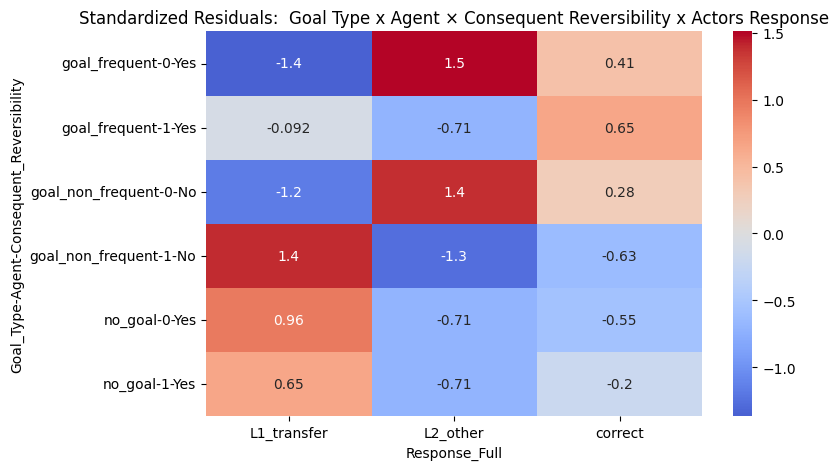

In [38]:
plt.figure(figsize=(8, 5))

sns.heatmap(
    residuals,
    annot=True,
    cmap="coolwarm",
    center=0
)

plt.title("Standardized Residuals:  Goal Type x Agent × Consequent Reversibility x Actors Response")
plt.show()

7. Interpretation

Neither the overall theoretical subgroup nor the actors subgroup showed a significant association between Consequent Reversibility and response type. Effect sizes were small to negligible (V = .104 and V = .038 respectively). Standardized residuals revealed no meaningful departures from expected frequencies among actors. These findings indicate that reversibility alone does not account for response choice and suggest that any potential influence of reversibility may emerge only in interaction with other theoretically relevant variables such as Agency and Goal Type. 

**Consequent Reversability is not a main effect.**
